In [1]:
# imports
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from dataset import BraTSDataset
from model import UNet
from dice_loss import DiceLoss
from dataset import get_dataloaders
from train import train_epoch, validate
import glob
from sklearn.model_selection import train_test_split

In [2]:
# set up hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# initialize dataloaders
# TODO: Define file paths, instantiate BraTSDataset, and create PyTorch DataLoaders
data_path = "data/BraTS2020_training_data/content/data/*.h5"
all_files = glob.glob(data_path)

if len(all_files) == 0:
    print(f"Checking path: {os.path.abspath(data_path)}")
    print("Zero files found. Check if the unzip command actually put files in that folder.")
else:
    print("Number of files:", len(all_files))

    train_paths, val_paths = train_test_split(all_files, test_size=0.2, random_state=0)
    train_loader, val_loader = get_dataloaders(train_paths, val_paths, batch_size=4)
    
    # check dimensions
    for images, masks in train_loader:
        print(images.shape)
        print(masks.shape)
        break

Number of files: 155
torch.Size([4, 4, 240, 240])
torch.Size([4, 3, 240, 240])


In [4]:
# initialize model, loss, and optimizer
model = UNet(in_channels=4, out_channels=3).to(DEVICE)
criterion = DiceLoss()
# use adam optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [5]:
# main training loop

train_losses = []
val_losses = []
val_dices =[]
best_val_dice = 0.0

print("Starting training...")
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    # 1. Train for one epoch (using the function from train.py)
    # Note: Make sure train_loader and val_loader are defined in Cell 3!
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    
    # 2. Validate for one epoch (using the function from train.py)
    val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)
    
    # 3. Save metrics for plotting later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    
    # 4. Save the best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_model.pth")
        print(">>> Best model saved!")

print("Training Complete!")

Starting training...

--- Epoch 1/30 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  7.65it/s]


Train Loss: 0.9808 | Val Loss: 0.9847 | Val Dice: 0.0153
>>> Best model saved!

--- Epoch 2/30 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  7.84it/s]


Train Loss: 0.9758 | Val Loss: 0.9813 | Val Dice: 0.0187
>>> Best model saved!

--- Epoch 3/30 ---


...

Train Loss: 0.7846 | Val Loss: 0.8318 | Val Dice: 0.1682
>>> Best model saved!

--- Epoch 29/30 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  7.77it/s]


Train Loss: 0.7511 | Val Loss: 0.7956 | Val Dice: 0.2044
>>> Best model saved!

--- Epoch 30/30 ---


Validating: 100%|██████████| 8/8 [00:00<00:00,  8.06it/s]


Train Loss: 0.7260 | Val Loss: 0.7681 | Val Dice: 0.2319
>>> Best model saved!
Training Complete!


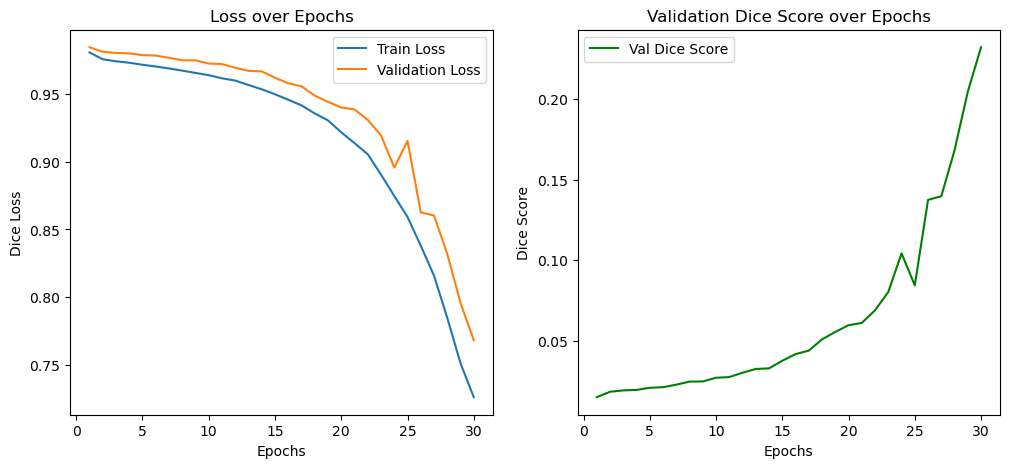

In [6]:
# plotting training graphs
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# plot losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.legend()

# plot dice score
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_dices, label='Val Dice Score', color='green')
plt.title('Validation Dice Score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.show()

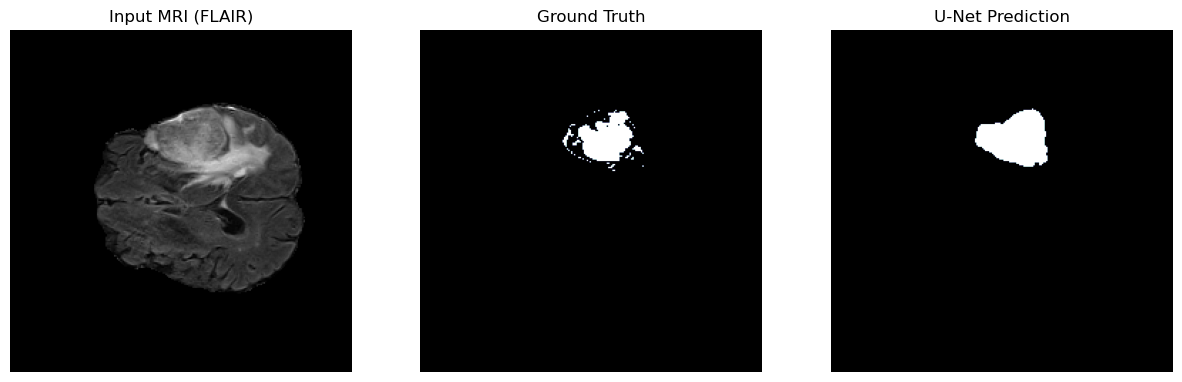

In [11]:
# visualize results

# Load the best weights
model.load_state_dict(torch.load("best_unet_model.pth"))
model.eval()

# Grab one batch of data from the validation set
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

# Find an index in the batch that actually has tumor pixels
idx = 0
for i in range(images.shape[0]):
    if masks[i].sum() > 0: # If there is a tumor in this slice
        idx = i
        break

# Get predictions
with torch.no_grad():
    outputs = model(images) 
    probabilities = torch.sigmoid(outputs)
    
    # Apply threshold to get binary masks for all 3 channels
    # Shape: [Batch, 3, 240, 240]
    predictions = (probabilities > 0.5).float()
    
    # Create the brain mask to clean up background noise
    # images shape is [Batch, 4, 240, 240]
    brain_mask = (images.sum(dim=1, keepdim=True) > 0.01).float()
    
    # Clean all 3 prediction channels
    clean_predicted = predictions * brain_mask

# Move tensors back to CPU for matplotlib
image_cpu = images[idx].cpu().numpy() 
mask_cpu = masks[idx].cpu().numpy()
pred_cpu = clean_predicted[idx].cpu().numpy()

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Displaying the FLAIR channel
axs[0].imshow(image_cpu[0], cmap='gray') 
axs[0].set_title('Input MRI (FLAIR)')
axs[0].axis('off')

# Displaying Ground Truth 
axs[1].imshow(mask_cpu[0], cmap='bone') 
axs[1].set_title('Ground Truth')
axs[1].axis('off')

# Displaying U-Net Prediction 
axs[2].imshow(pred_cpu[0], cmap='bone')
axs[2].set_title('U-Net Prediction')
axs[2].axis('off')

plt.show()